In [22]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [23]:
# Load the data
patients = pd.read_csv('../data/patients.csv', parse_dates=['admission_datetime', 'discharge_datetime'])
staff = pd.read_csv('../data/staff_schedule.csv', parse_dates=['shift_start', 'shift_end'])

print(f"Patients dataset: {patients.shape[0]} rows, {patients.shape[1]} columns")
print(f"Staff dataset: {staff.shape[0]} rows, {staff.shape[1]} columns")

Patients dataset: 5000 rows, 7 columns
Staff dataset: 10000 rows, 7 columns


In [24]:
# Quick look at patient data
print("PATIENTS DATA - First 5 rows:")
patients.head()

PATIENTS DATA - First 5 rows:


,admission_id,patient_id,admission_datetime,discharge_datetime,department,acuity_level,age_group
0,1,6580a7fd-7457-46dd-881c-f0778734acb0,2023-10-31 02:13:58,2023-11-01 08:13:58,Cardiology,2,child
1,2,251062fe-2968-4b8e-8891-4afcf395bf05,2023-02-11 13:05:50,NaT,Emergency,1,senior
2,3,a27589c3-f336-442f-9f9d-63820a2bc9e7,2023-01-07 05:12:32,2023-01-08 15:12:32,Emergency,4,adult
3,4,416d7957-8dfc-4f45-9d5c-a0eafb9b293c,2023-07-25 13:20:16,2023-07-26 08:20:16,Surgery,2,child
4,5,5b06c758-2e3a-4a10-b1bc-128ed858512f,2023-05-08 09:31:38,2023-05-08 18:31:38,Surgery,1,child


In [25]:
# Patient data info
print("\nPATIENTS DATA INFO:")
patients.info()


PATIENTS DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   admission_id        5000 non-null   int64         
 1   patient_id          5000 non-null   object        
 2   admission_datetime  5000 non-null   datetime64[ns]
 3   discharge_datetime  4521 non-null   datetime64[ns]
 4   department          5000 non-null   object        
 5   acuity_level        5000 non-null   int64         
 6   age_group           5000 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 273.6+ KB


In [26]:
# Summary statistics for patients
print("\nPATIENTS SUMMARY STATISTICS:")
patients.describe(include='all')


PATIENTS SUMMARY STATISTICS:


,admission_id,patient_id,admission_datetime,discharge_datetime,department,acuity_level,age_group
count,5000.000000,5000,5000,4521,5000,5000.000000,5000
unique,NaN,5000,NaN,NaN,5,NaN,3
top,NaN,6580a7fd-7457-46dd-881c-f0778734acb0,NaN,NaN,Emergency,NaN,adult
freq,NaN,1,NaN,NaN,1962,NaN,2519
mean,2500.500000,NaN,2023-07-03 14:46:58.270600192,2023-07-05 04:01:17.670427136,NaN,2.499200,NaN
min,1.000000,NaN,2023-01-01 01:31:34,2023-01-01 11:31:34,NaN,1.000000,NaN
25%,1250.750000,NaN,2023-04-01 00:57:02.249999872,2023-04-02 16:56:00,NaN,1.000000,NaN
50%,2500.500000,NaN,2023-07-06 22:05:20.500000,2023-07-08 20:34:55,NaN,2.000000,NaN
75%,3750.250000,NaN,2023-10-03 01:42:02.249999872,2023-10-04 22:02:40,NaN,4.000000,NaN
max,5000.000000,NaN,2023-12-30 17:56:52,2024-01-01 18:27:37,NaN,5.000000,NaN


In [27]:
# Check for missing values
print("Missing values in patients:")
print(patients.isnull().sum())
print("\nMissing values in staff:")
print(staff.isnull().sum())

Missing values in patients:
admission_id            0
patient_id              0
admission_datetime      0
discharge_datetime    479
department              0
acuity_level            0
age_group               0
dtype: int64

Missing values in staff:
shift_id       0
staff_id       0
role           0
department     0
shift_start    0
shift_end      0
shift_type     0
dtype: int64


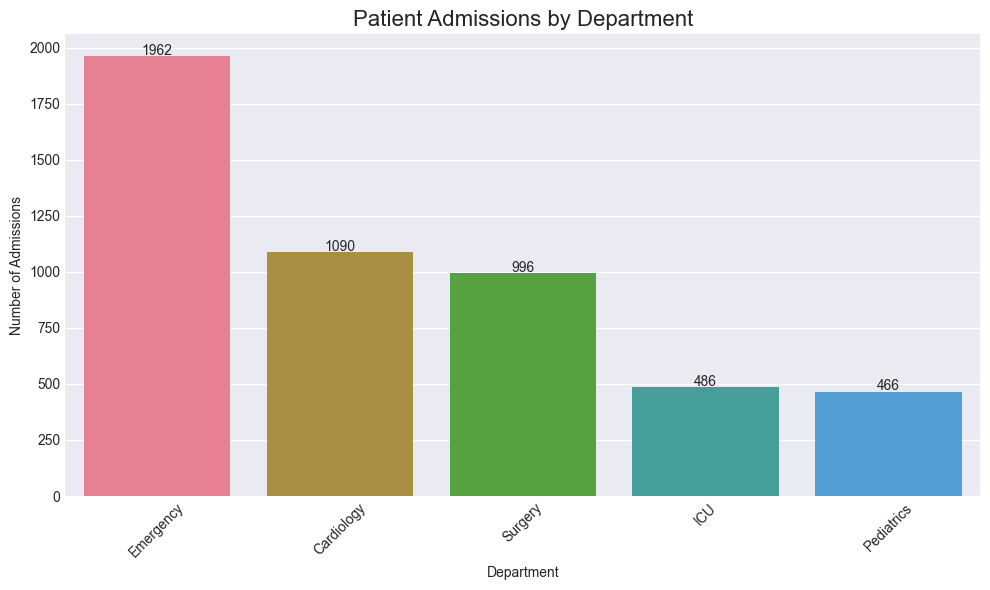

In [28]:
# Patient admissions by department
dept_counts = patients['department'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=dept_counts.index, y=dept_counts.values)
plt.title('Patient Admissions by Department', fontsize=16)
plt.xlabel('Department')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
for i, v in enumerate(dept_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

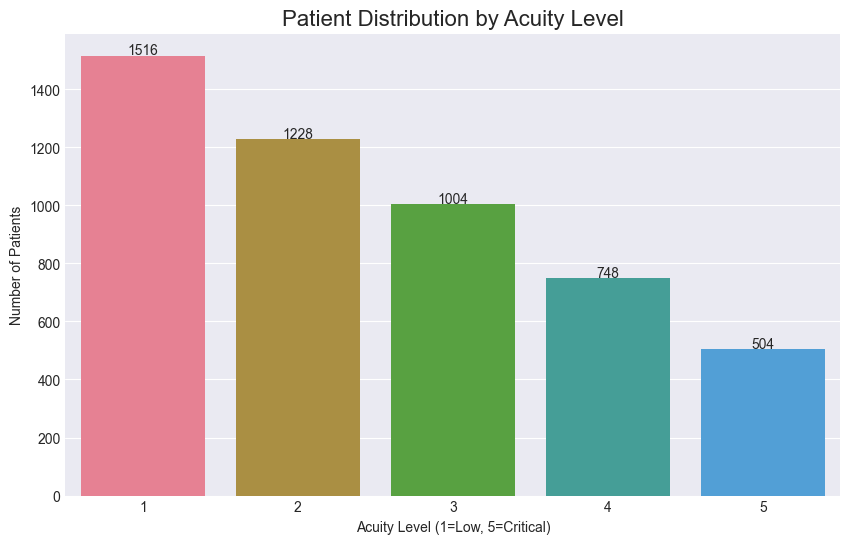

In [29]:
# Patient acuity distribution
acuity_counts = patients['acuity_level'].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=acuity_counts.index, y=acuity_counts.values)
plt.title('Patient Distribution by Acuity Level', fontsize=16)
plt.xlabel('Acuity Level (1=Low, 5=Critical)')
plt.ylabel('Number of Patients')
for i, v in enumerate(acuity_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

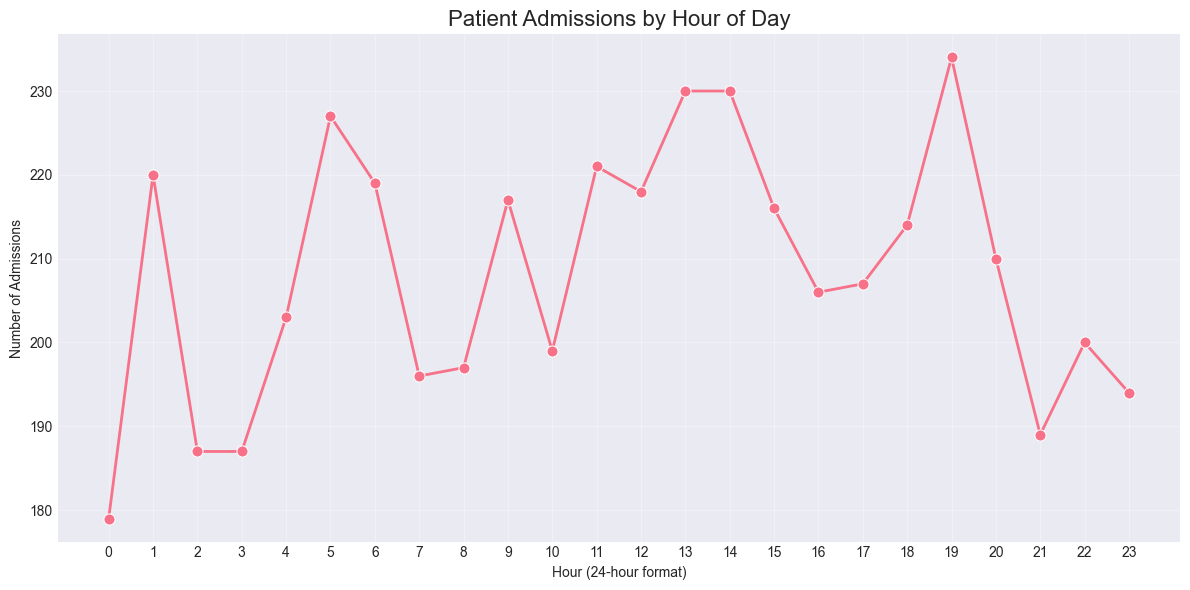

In [30]:
# Admissions by hour
patients['hour'] = patients['admission_datetime'].dt.hour
hourly_admissions = patients.groupby('hour').size()

plt.figure(figsize=(12,6))
sns.lineplot(x=hourly_admissions.index, y=hourly_admissions.values, marker='o', linewidth=2, markersize=8)
plt.title('Patient Admissions by Hour of Day', fontsize=16)
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Number of Admissions')
plt.grid(True, alpha=0.3)
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

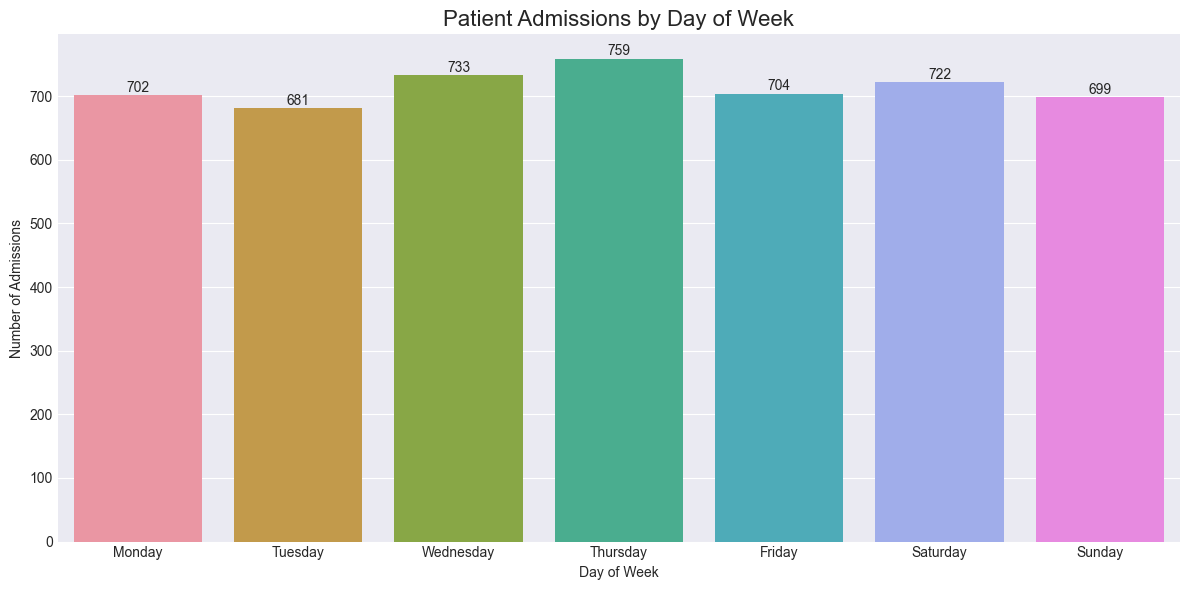

In [31]:
# Admissions by day of week
patients['day_of_week'] = patients['admission_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_admissions = patients['day_of_week'].value_counts().reindex(day_order)

plt.figure(figsize=(12,6))
sns.barplot(x=daily_admissions.index, y=daily_admissions.values)
plt.title('Patient Admissions by Day of Week', fontsize=16)
plt.xlabel('Day of Week')
plt.ylabel('Number of Admissions')
for i, v in enumerate(daily_admissions.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

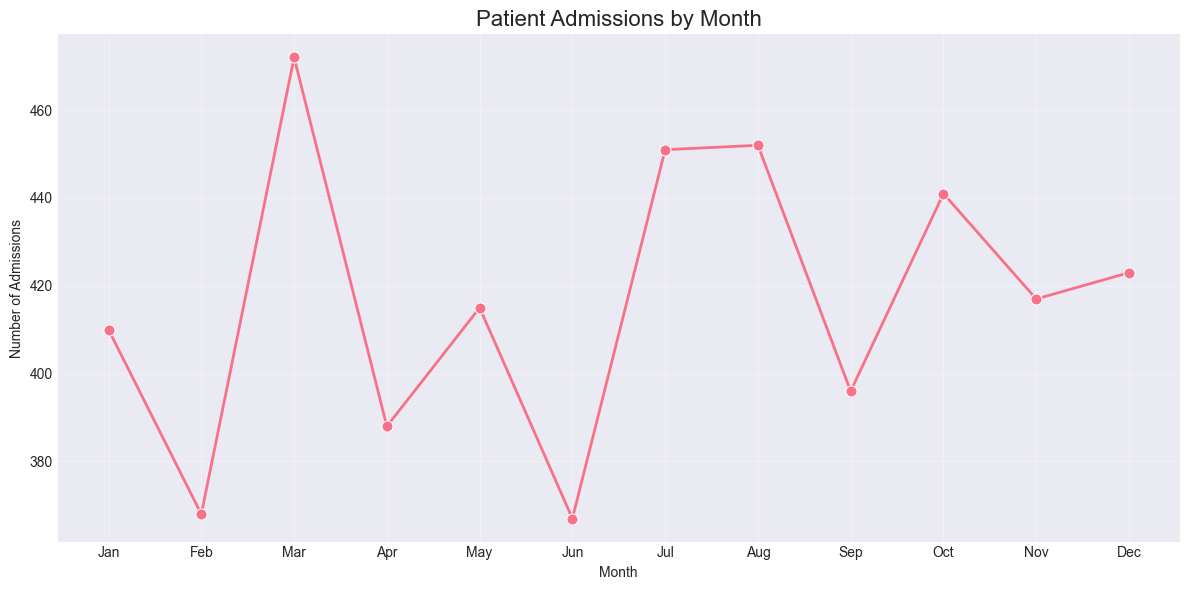

In [32]:
# Admissions by month
patients['month'] = patients['admission_datetime'].dt.month
monthly_admissions = patients.groupby('month').size()

plt.figure(figsize=(12,6))
sns.lineplot(x=monthly_admissions.index, y=monthly_admissions.values, marker='o', linewidth=2, markersize=8)
plt.title('Patient Admissions by Month', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.grid(True, alpha=0.3)
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

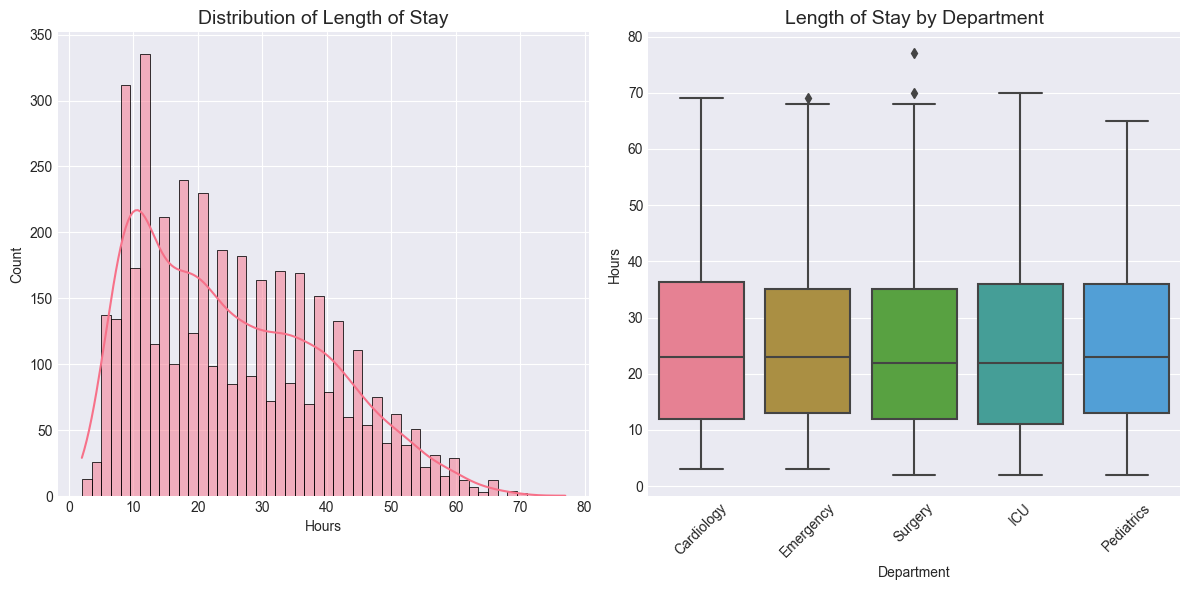

In [33]:
# Length of stay analysis
patients['length_of_stay_hours'] = (patients['discharge_datetime'] - patients['admission_datetime']).dt.total_seconds() / 3600

# Filter out still admitted patients
completed_stays = patients[patients['discharge_datetime'].notna()]

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(completed_stays['length_of_stay_hours'], bins=50, kde=True)
plt.title('Distribution of Length of Stay', fontsize=14)
plt.xlabel('Hours')

plt.subplot(1,2,2)
sns.boxplot(x='department', y='length_of_stay_hours', data=completed_stays)
plt.title('Length of Stay by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Hours')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

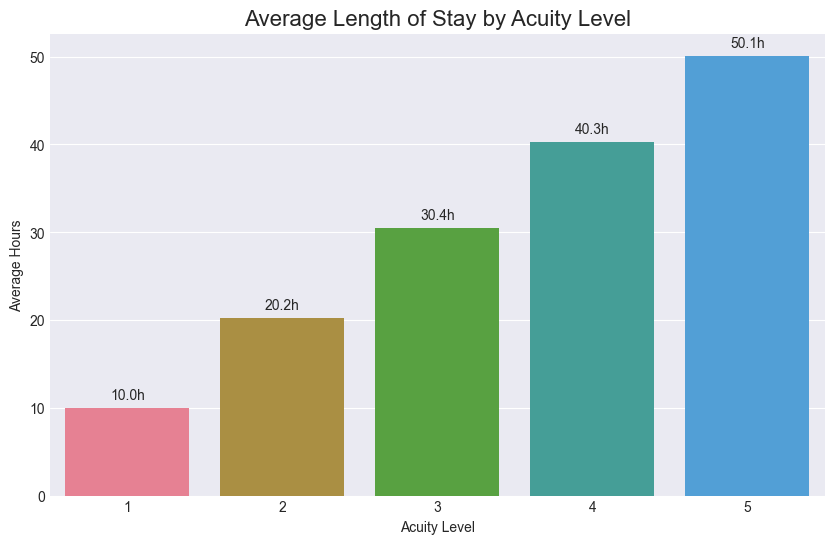

In [34]:
# Average length of stay by acuity
avg_los_acuity = completed_stays.groupby('acuity_level')['length_of_stay_hours'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='acuity_level', y='length_of_stay_hours', data=avg_los_acuity)
plt.title('Average Length of Stay by Acuity Level', fontsize=16)
plt.xlabel('Acuity Level')
plt.ylabel('Average Hours')
for i, v in enumerate(avg_los_acuity['length_of_stay_hours']):
    plt.text(i, v + 1, f'{v:.1f}h', ha='center')
plt.show()

In [35]:
# STAFF ANALYSIS
print("STAFF SCHEDULE DATA - First 5 rows:")
staff.head()

STAFF SCHEDULE DATA - First 5 rows:


,shift_id,staff_id,role,department,shift_start,shift_end,shift_type
0,1,960c93c4-72c4-432e-870f-f448f6979f79,nurse,Emergency,2023-10-20 15:00:38,2023-10-20 23:00:38,evening
1,2,5fa0ec94-c36f-4984-8d93-00aa5302d3aa,nurse,Surgery,2023-12-02 15:00:00,2023-12-02 23:00:00,evening
2,3,604e6ff4-16eb-48c6-9197-38f6a7d6502b,doctor,Cardiology,2023-08-08 23:00:02,2023-08-09 09:00:02,night
3,4,547d37d2-e522-48b0-97d4-e856ca0084e4,doctor,ICU,2023-07-09 23:00:40,2023-07-10 09:00:40,night
4,5,c9bccbac-6084-4067-81b0-400b45641111,nurse,ICU,2023-01-25 15:00:56,2023-01-25 23:00:56,evening


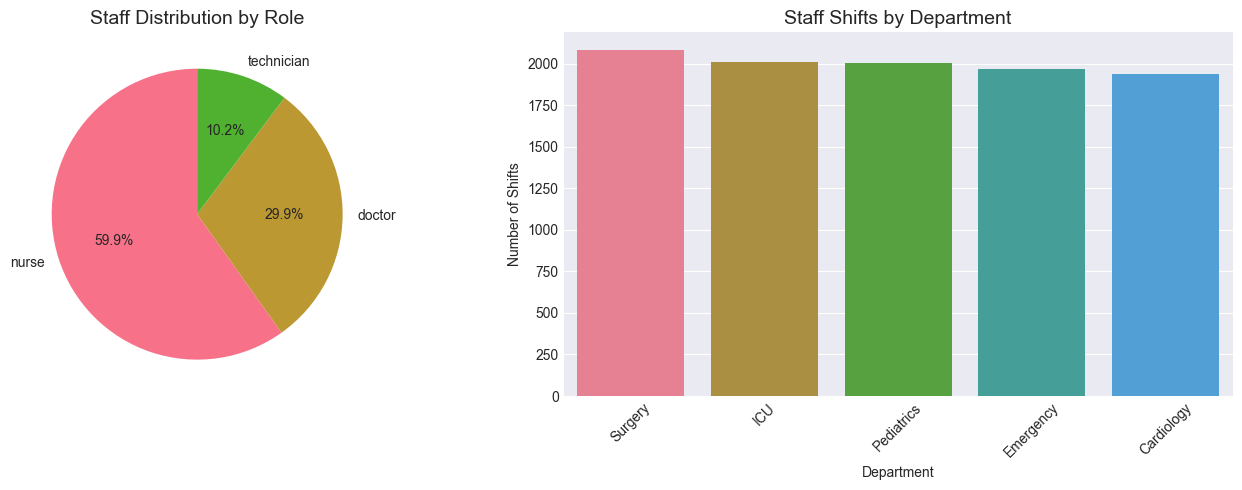

In [36]:
# Staff by role and department
staff_by_role = staff['role'].value_counts()
staff_by_dept = staff['department'].value_counts()

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.pie(staff_by_role.values, labels=staff_by_role.index, autopct='%1.1f%%', startangle=90)
plt.title('Staff Distribution by Role', fontsize=14)

plt.subplot(1,2,2)
sns.barplot(x=staff_by_dept.index, y=staff_by_dept.values)
plt.title('Staff Shifts by Department', fontsize=14)
plt.xlabel('Department')
plt.ylabel('Number of Shifts')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

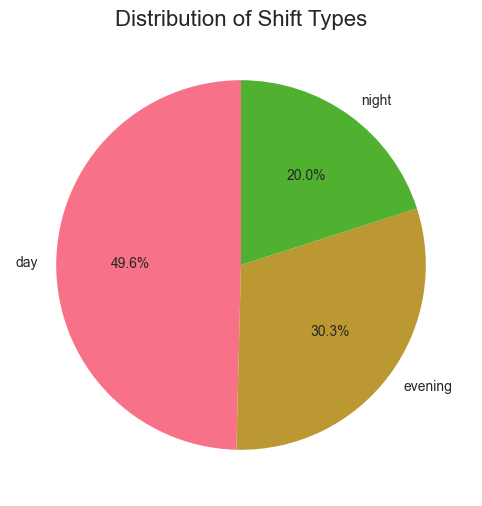

In [37]:
# Shift type distribution
shift_types = staff['shift_type'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(shift_types.values, labels=shift_types.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Shift Types', fontsize=16)
plt.show()

In [38]:
# Function to expand shifts to hourly coverage
def expand_shifts_to_hourly(df):
    """Convert shift data to hourly coverage"""
    rows = []
    for _, row in df.iterrows():
        start = row['shift_start']
        end = row['shift_end']
        # Create hourly intervals
        current = start
        while current < end:
            rows.append({
                'datetime': current,
                'hour': current.hour,
                'department': row['department'],
                'role': row['role'],
                'staff_id': row['staff_id']
            })
            current += pd.Timedelta(hours=1)
    return pd.DataFrame(rows)

print("Expanding shifts to hourly coverage (this may take a moment)...")
hourly_coverage = expand_shifts_to_hourly(staff)
print(f"Created {len(hourly_coverage)} hourly records")

Expanding shifts to hourly coverage (this may take a moment)...
Created 84010 hourly records


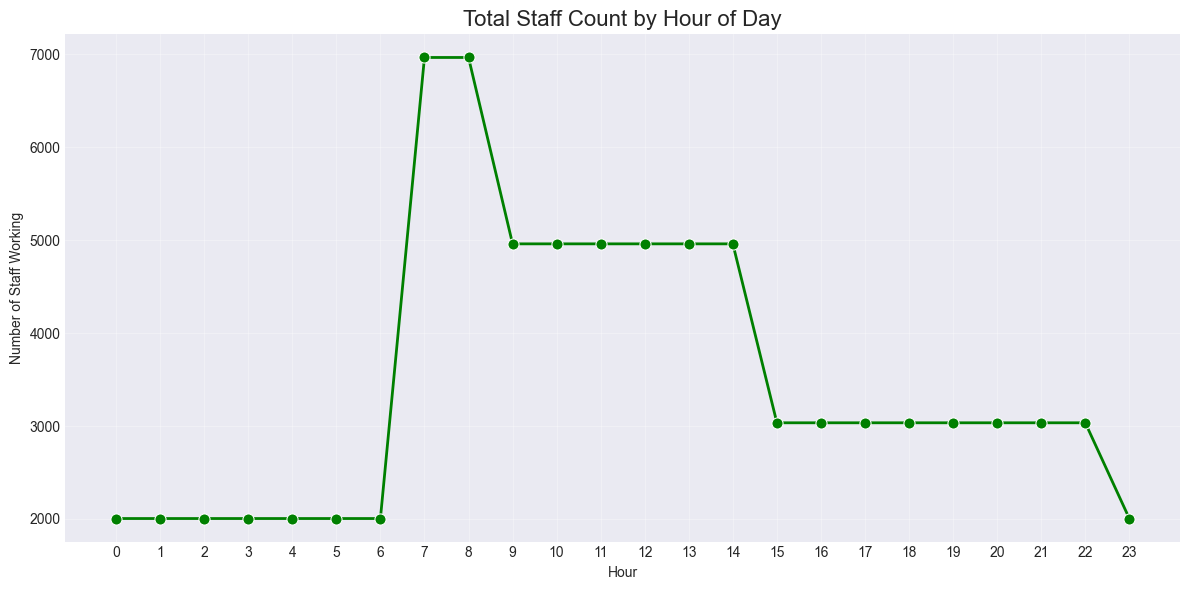

In [39]:
# Staff count by hour
hourly_staff_count = hourly_coverage.groupby('hour').size()

plt.figure(figsize=(12,6))
sns.lineplot(x=hourly_staff_count.index, y=hourly_staff_count.values, marker='o', linewidth=2, markersize=8, color='green')
plt.title('Total Staff Count by Hour of Day', fontsize=16)
plt.xlabel('Hour')
plt.ylabel('Number of Staff Working')
plt.grid(True, alpha=0.3)
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

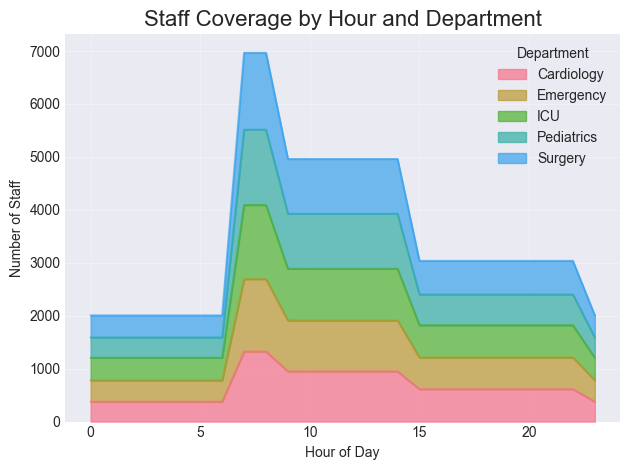

In [40]:
# Staff by hour and department
hourly_dept_staff = hourly_coverage.groupby(['hour', 'department']).size().unstack()

plt.figure(figsize=(14,8))
hourly_dept_staff.plot.area(alpha=0.7)
plt.title('Staff Coverage by Hour and Department', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Staff')
plt.grid(True, alpha=0.3)
plt.legend(title='Department')
plt.tight_layout()
plt.show()

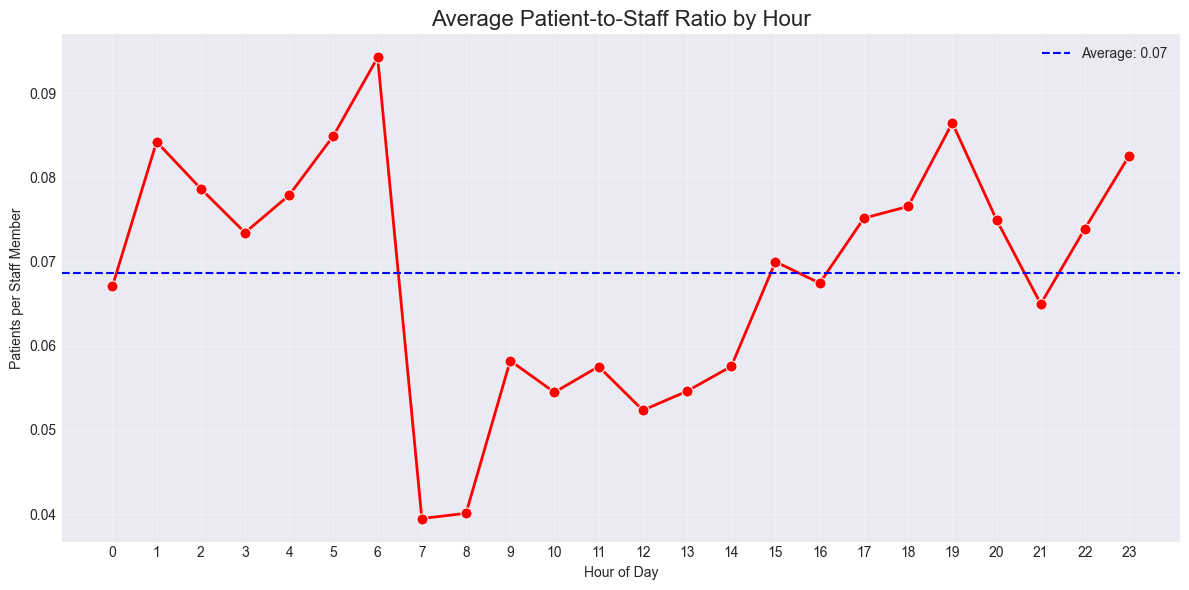

In [41]:
# PATIENT TO STAFF RATIO ANALYSIS

# Get hourly patient counts
patients['hour'] = patients['admission_datetime'].dt.hour
patients['date_hour'] = patients['admission_datetime'].dt.floor('H')
hourly_patients = patients.groupby(['date_hour', 'department']).size().reset_index(name='patient_count')

# Get hourly staff counts
hourly_coverage['date_hour'] = hourly_coverage['datetime'].dt.floor('H')
hourly_staff = hourly_coverage.groupby(['date_hour', 'department']).agg(
    staff_count=('staff_id', 'nunique')
).reset_index()

# Merge
merged = pd.merge(hourly_patients, hourly_staff, on=['date_hour', 'department'], how='outer').fillna(0)
merged['patient_to_staff_ratio'] = merged['patient_count'] / merged['staff_count'].replace(0, np.nan)

# Average ratio by hour
hourly_ratio = merged.groupby(merged['date_hour'].dt.hour)['patient_to_staff_ratio'].mean()

plt.figure(figsize=(12,6))
sns.lineplot(x=hourly_ratio.index, y=hourly_ratio.values, marker='o', linewidth=2, markersize=8, color='red')
plt.title('Average Patient-to-Staff Ratio by Hour', fontsize=16)
plt.xlabel('Hour of Day')
plt.ylabel('Patients per Staff Member')
plt.grid(True, alpha=0.3)
plt.axhline(y=hourly_ratio.mean(), color='blue', linestyle='--', label=f'Average: {hourly_ratio.mean():.2f}')
plt.legend()
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

In [42]:
# Key insights summary
print("="*50)
print("KEY INSIGHTS FROM EDA")
print("="*50)
print(f"1. Total Patients Analyzed: {len(patients)}")
print(f"2. Total Staff Shifts: {len(staff)}")
print(f"3. Busiest Department: {dept_counts.index[0]} ({dept_counts.values[0]} admissions)")
print(f"4. Most Common Acuity Level: {acuity_counts.index[0]} ({acuity_counts.values[0]} patients)")
print(f"5. Peak Admission Hour: {hourly_admissions.idxmax()}:00 ({hourly_admissions.max()} admissions)")
print(f"6. Busiest Day: {daily_admissions.idxmax()} ({daily_admissions.max()} admissions)")
print(f"7. Average Length of Stay: {completed_stays['length_of_stay_hours'].mean():.1f} hours")
print(f"8. Average Patient-to-Staff Ratio: {hourly_ratio.mean():.2f} patients per staff")
print(f"9. Most Common Shift Type: {shift_types.index[0]} ({shift_types.values[0]} shifts)")
print("="*50)

KEY INSIGHTS FROM EDA
1. Total Patients Analyzed: 5000
2. Total Staff Shifts: 10000
3. Busiest Department: Emergency (1962 admissions)
4. Most Common Acuity Level: 1 (1516 patients)
5. Peak Admission Hour: 19:00 (234 admissions)
6. Busiest Day: Thursday (759 admissions)
7. Average Length of Stay: 25.2 hours
8. Average Patient-to-Staff Ratio: 0.07 patients per staff
9. Most Common Shift Type: day (4960 shifts)
